In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 147.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [3]:
from roboflow import Roboflow
camera = "A3" #A4

# **Choice Test Data**

In [4]:
if camera == "A3":
  IOU_MATCH_THRESHOLD = 0.3
  #A3 example -> ต้อง resize fit (black edges in) เท่านั้นโปรแกรมนี้ถึงจะ work (OK), Auto-Orient: Applied (OK), no augmentation (OK), train 85%, valid 15% (OK)
  # workspace_name = "cowlabela3new"
  # camera = "A3"
  # api = "3B2bsTvSHbW74lGdB4Pp"

  #Test dataset -> ต้อง resize fit (black edges in) (OK), Auto-Orient: Applied (OK), no augmentation (OK)
  A3_fix_method = "white edge" #black edge, #white edge, stretch
  workspace_name_test = "cow-a3"
  api_test = "xVvP37DLhcYDlZ3cr9yX"
  #Test dataset -> ต้อง resize fit (black edges in) (OK), Auto-Orient: Applied (OK), no augmentation (OK)
  project_name_test = "1705-cowlebel-a03"
  project_version_test = 8 #No resizing!

elif  camera == "A4":
  IOU_MATCH_THRESHOLD = 0.3
  #A4 example -> ต้อง resize fit (black edges in) (OK) เท่านั้นโปรแกรมนี้ถึงจะ work, Auto-Orient: Applied (OK), no augmentation (OK)
  workspace_name_test = workspace_name = "cowlabel-vknw5"
  api_test = api = "Wc8955yqAwHYuTac7CLh"
  # project_name = "j-run3"
  # project_version = 5

  #Test dataset -> ต้อง resize fit (black edges in) (OK), Auto-Orient: Applied (OK), no augmentation (OK)
  project_name_test = "mounted_1705_cowlebel"
  #project_version_test = 4 #Fit black edges in
  project_version_test = 8 #No resizing


#Load train/validation data
# rf = Roboflow(api_key=api)
# project = rf.workspace(workspace_name).project(project_name)
# version = project.version(project_version)
# dataset = version.download("yolov8")

#Load test data on different dataset
rf = Roboflow(api_key=api_test)
project = rf.workspace(workspace_name_test).project(project_name_test)
version = project.version(project_version_test)
dataset2 = version.download("yolov8")



image_enhancement = False
verify_fixing = True
suppress = True

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 1705-cowlebel-A03-8 in yolov8:: 100%|██████████| 544/544 [00:00<00:00, 4885.57it/s]


# Preprocess dataset for A4

In [ ]:
def fix_bounding_boxes(boxes, orig_w, orig_h, crop_x, crop_y, target_size):
    fixed = []
    for box in boxes:
        cls = int(box[0])
        x_rel, y_rel, w_rel, h_rel = box[1:5]
        conf = box[5] if len(box) == 6 else 1.0

        x_abs = x_rel * orig_w
        y_abs = y_rel * orig_h
        w_abs = w_rel * orig_w
        h_abs = h_rel * orig_h

        x1 = x_abs - w_abs / 2
        y1 = y_abs - h_abs / 2
        x2 = x_abs + w_abs / 2
        y2 = y_abs + h_abs / 2

        x1 -= crop_x
        x2 -= crop_x
        y1 -= crop_y
        y2 -= crop_y

        if x2 <= 0 or x1 >= target_size or y2 <= 0 or y1 >= target_size:
            continue

        x1 = max(0, min(x1, target_size))
        x2 = max(0, min(x2, target_size))
        y1 = max(0, min(y1, target_size))
        y2 = max(0, min(y2, target_size))

        w_new = x2 - x1
        h_new = y2 - y1
        x_center_new = x1 + w_new / 2
        y_center_new = y1 + h_new / 2

        x_rel_new = x_center_new / target_size
        y_rel_new = y_center_new / target_size
        w_rel_new = w_new / target_size
        h_rel_new = h_new / target_size

        if w_rel_new <= 0 or h_rel_new <= 0:
            continue

        fixed.append([cls, x_rel_new, y_rel_new, w_rel_new, h_rel_new, conf] if len(box) == 6 else [cls, x_rel_new, y_rel_new, w_rel_new, h_rel_new])
    return fixed

In [ ]:
def center_crop_frame(img):
    h, w, _ = img.shape
    if h == w:
        return img, 0, 0

    if w > h:
        offset = (w - h) // 2
        return img[:, offset:offset+h], offset, 0
    else:
        offset = (h - w) // 2
        return img[offset:offset+w, :], 0, offset

In [ ]:
import os
from tqdm import tqdm
import cv2
import numpy as np
import matplotlib.pyplot as plt
def fix_dataset_A4_with_crop(dataset):
    dataset_path = dataset.location
    for split in ["train", "valid", "test"]:
        input_dir = os.path.join(dataset_path, split, "images")
        label_dir = os.path.join(dataset_path, split, "labels")
        output_label_dir = label_dir  # Overwrite
        output_dir = input_dir        # Overwrite
        if not os.path.exists(input_dir):
            continue

        count = 0
        for filename in tqdm(os.listdir(input_dir)):
            if not filename.endswith(('.jpg', '.png', '.jpeg')):
                continue

            image_path = os.path.join(input_dir, filename)
            name = os.path.splitext(filename)[0]
            label_path = os.path.join(label_dir, name + ".txt")

            image = cv2.imread(image_path)
            prev_height, prev_width = image.shape[:2]

            # Center crop the image
            image, crop_x, crop_y = center_crop_frame(image)
            cropped_size = image.shape[0]

            # Resize to 640x640
            resized_image = cv2.resize(image, (640, 640))
            resized_size = 640

            # Save the resized image (overwrite)
            output_path = os.path.join(output_dir, filename)
            cv2.imwrite(output_path, resized_image)

            # Fix and save corresponding label
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    boxes = [list(map(float, line.strip().split())) for line in f if line.strip()]

                # First fix based on crop
                fixed_boxes = fix_bounding_boxes(boxes, prev_width, prev_height, crop_x, crop_y, cropped_size)

                # Then adjust coordinates to resized image
                # Since both input and output are square, scaling is simple
                scale = resized_size / cropped_size
                final_boxes = []
                for b in fixed_boxes:
                    cls = int(b[0])
                    x, y, w, h = b[1:5]
                    final_boxes.append([cls, x, y, w, h] if len(b) == 5 else [cls, x, y, w, h, b[5]])

                # Save updated labels
                with open(os.path.join(output_label_dir, name + '.txt'), 'w') as f:
                    for b in final_boxes:
                        cls = int(b[0])
                        rest = b[1:]
                        line = f"{cls} " + ' '.join(f'{x:.6f}' for x in rest) + '\n'
                        f.write(line)

                # Optionally plot some images to verify
                # count += 1
                # if count < 20:
                #     plt.figure(figsize=(10, 5))
                #     img_vis = draw_boxes2(resized_image.copy(), final_boxes, class_names)
                #     plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
                #     plt.title(f"{split}/{filename}")
                #     plt.axis("off")
                #     plt.show()

In [ ]:
  if camera == "A4":
    # if project_name == "j-run3" and project_version == 14:
    #   fix_dataset_A4_with_crop(dataset)
    #   print("A4 Dataset fixed for train/valid data")
    if project_name_test == "1705_cowlebel" and project_version_test == 8:
      fix_dataset_A4_with_crop(dataset2)
      print("A4 Dataset fixed for test data")

#Preprocess dataset for A3

In [5]:
def get_crop_bounds(image, threshold=30, dark_pixel_ratio=0.95):
    """
    Detect black border and return crop coordinates.
    threshold: intensity value below which a pixel is considered dark
    dark_pixel_ratio: minimum ratio of dark pixels in a row/col to be considered black

    Returns: x_start, y_start, x_end, y_end
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)  # smooth to remove text noise

    h, w = blurred.shape
    # Detect dark rows
    row_dark = np.mean(blurred < threshold, axis=1) > dark_pixel_ratio
    col_dark = np.mean(blurred < threshold, axis=0) > dark_pixel_ratio

    # Invert logic: we want rows/cols that are NOT mostly black
    valid_rows = np.where(~row_dark)[0]
    valid_cols = np.where(~col_dark)[0]

    if len(valid_rows) == 0 or len(valid_cols) == 0:
        return 0, 0, w, h  # fallback

    y_start, y_end = valid_rows[[0, -1]]
    x_start, x_end = valid_cols[[0, -1]]

    return x_start, y_start, x_end, y_end

In [6]:
def fix_bounding_boxes_from_crop(
        boxes, orig_w, orig_h,
        x_start, y_start, crop_w, crop_h,
        scale_x, scale_y,
        offset_x=0, offset_y=0):
    fixed = []
    for box in boxes:
        cls = int(box[0])
        x_rel, y_rel, w_rel, h_rel = box[1:5]

        x_abs = x_rel * orig_w
        y_abs = y_rel * orig_h
        w_abs = w_rel * orig_w
        h_abs = h_rel * orig_h

        x1 = x_abs - w_abs / 2 - x_start
        y1 = y_abs - h_abs / 2 - y_start
        x2 = x_abs + w_abs / 2 - x_start
        y2 = y_abs + h_abs / 2 - y_start

        # Add offset for padding
        x1 += offset_x
        x2 += offset_x
        y1 += offset_y
        y2 += offset_y

        x1 = max(0, min(x1, crop_w + offset_x * 2))
        x2 = max(0, min(x2, crop_w + offset_x * 2))
        y1 = max(0, min(y1, crop_h + offset_y * 2))
        y2 = max(0, min(y2, crop_h + offset_y * 2))

        x1 *= scale_x
        x2 *= scale_x
        y1 *= scale_y
        y2 *= scale_y

        w_new = x2 - x1
        h_new = y2 - y1
        x_center_new = x1 + w_new / 2
        y_center_new = y1 + h_new / 2

        x_rel_new = x_center_new / 640
        y_rel_new = y_center_new / 640
        w_rel_new = w_new / 640
        h_rel_new = h_new / 640

        if w_rel_new <= 0 or h_rel_new <= 0:
            continue

        fixed.append([cls, x_rel_new, y_rel_new, w_rel_new, h_rel_new])
    return fixed

In [7]:
def draw_boxes_true(image, boxes, class_names, color=(0, 0, 255)): #BGR
    h, w = image.shape[:2]
    for cls, x, y, bw, bh in boxes:
        x1, y1, x2, y2 = xywh_to_xyxy(x, y, bw, bh, w, h)
        label = class_names[int(cls)]
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, label, (x1, max(20, y1 - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return image

In [8]:
#Get class names
import yaml
import os
with open(os.path.join(dataset2.location, "data.yaml")) as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml["names"]  # List of class names

In [9]:
def xywh_to_xyxy(x_center, y_center, w, h, img_w, img_h):
    x1 = int((x_center - w / 2) * img_w)
    y1 = int((y_center - h / 2) * img_h)
    x2 = int((x_center + w / 2) * img_w)
    y2 = int((y_center + h / 2) * img_h)
    return x1, y1, x2, y2

In [10]:
class_names

['drink', 'eat', 'lay', 'propping', 'ride', 'stand']

In [11]:
import os
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
def fix_dataset_A3(dataset, A3_fix_method="stretch"):
    dataset_path = dataset.location
    final_size = 640

    for split in ["train", "valid", "test"]:
        image_dir = os.path.join(dataset_path, split, "images")
        label_dir = os.path.join(dataset_path, split, "labels")
        if not os.path.exists(image_dir):
            continue

        count = 0
        for filename in tqdm(os.listdir(image_dir)):
            if not filename.lower().endswith(('.jpg', '.png', '.jpeg')):
                continue

            image_path = os.path.join(image_dir, filename)
            name = os.path.splitext(filename)[0]
            label_path = os.path.join(label_dir, name + ".txt")

            image = cv2.imread(image_path)
            orig_h, orig_w = image.shape[:2]

            x_start, y_start, x_end, y_end = get_crop_bounds(image)
            cropped = image[y_start:y_end+1, x_start:x_end+1]
            crop_h, crop_w = cropped.shape[:2]

            # Apply the requested fix method
            pad_top, pad_bottom, pad_left, pad_right = 0, 0, 0, 0

            if A3_fix_method == "stretch":
                fixed_image = cv2.resize(cropped, (final_size, final_size))
                scale_x = final_size / crop_w
                scale_y = final_size / crop_h
                offset_x, offset_y = 0, 0

            elif A3_fix_method in ["black edge", "white edge"]:
                # Choose real color and verify color
                real_color = (0, 0, 0) if A3_fix_method == "black edge" else (255, 255, 255)
                verify_color = real_color

                if crop_w > crop_h:
                    pad_total = crop_w - crop_h
                    pad_top = pad_total // 2
                    pad_bottom = pad_total - pad_top
                    padded = cv2.copyMakeBorder(
                        cropped, pad_top, pad_bottom, 0, 0,
                        cv2.BORDER_CONSTANT, value=verify_color
                    )
                elif crop_h > crop_w:
                    pad_total = crop_h - crop_w
                    pad_left = pad_total // 2
                    pad_right = pad_total - pad_left
                    padded = cv2.copyMakeBorder(
                        cropped, 0, 0, pad_left, pad_right,
                        cv2.BORDER_CONSTANT, value=verify_color
                    )
                else:
                    padded = cropped.copy()

                fixed_image = cv2.resize(padded, (final_size, final_size))
                scale_x = final_size / max(crop_w, crop_h)
                scale_y = final_size / max(crop_w, crop_h)
                offset_x = pad_left
                offset_y = pad_top
            else:
                raise ValueError(f"Invalid A3_fix_method: {A3_fix_method}")

            cv2.imwrite(image_path, fixed_image)

            # Fix labels
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    boxes = [list(map(float, line.strip().split())) for line in f if line.strip()]

                fixed_boxes = fix_bounding_boxes_from_crop(
                    boxes, orig_w, orig_h, x_start, y_start, crop_w, crop_h, scale_x, scale_y, offset_x, offset_y
                )

                with open(label_path, 'w') as f:
                    for b in fixed_boxes:
                        cls = int(b[0])
                        rest = b[1:]
                        f.write(f"{cls} " + ' '.join(f"{x:.6f}" for x in rest) + '\n')

                if verify_fixing:
                  count += 1
                  if count < 20:

                      plt.figure(figsize=(10, 5))
                      img_vis = draw_boxes_true(fixed_image.copy(), fixed_boxes, class_names)
                      plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
                      plt.axis("off")
                      plt.show()

  0%|          | 0/269 [00:00<?, ?it/s]

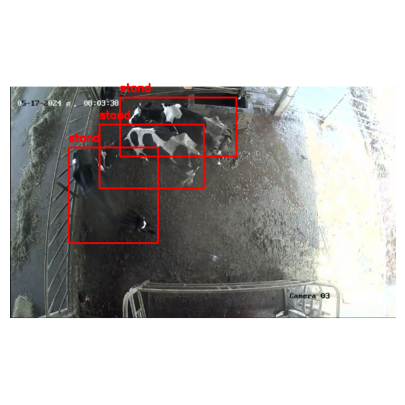

  0%|          | 1/269 [00:00<00:41,  6.49it/s]

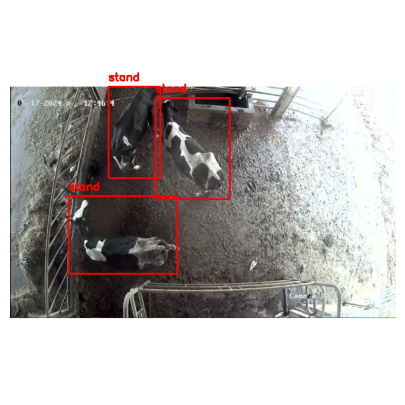

  1%|          | 2/269 [00:00<00:35,  7.52it/s]

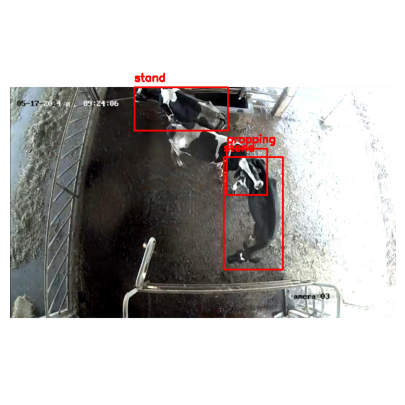

  1%|          | 3/269 [00:00<00:37,  7.17it/s]

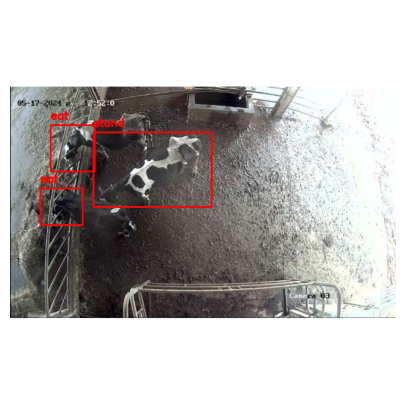

  1%|▏         | 4/269 [00:00<00:34,  7.69it/s]

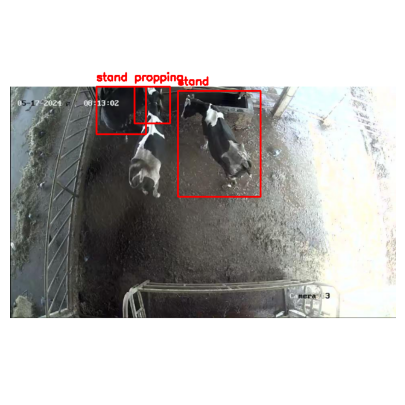

  2%|▏         | 5/269 [00:00<00:33,  7.86it/s]

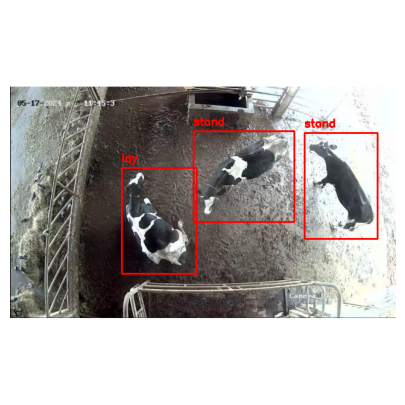

  2%|▏         | 6/269 [00:00<00:32,  8.03it/s]

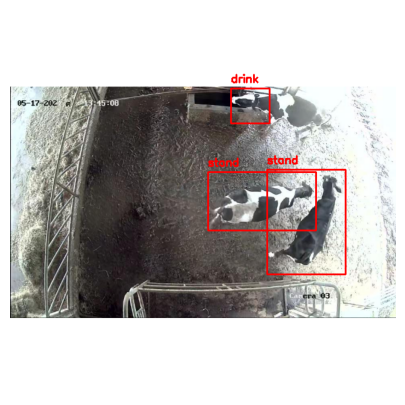

  3%|▎         | 7/269 [00:00<00:32,  8.05it/s]

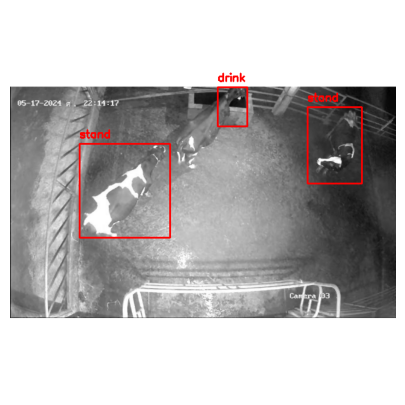

  3%|▎         | 8/269 [00:01<00:31,  8.21it/s]

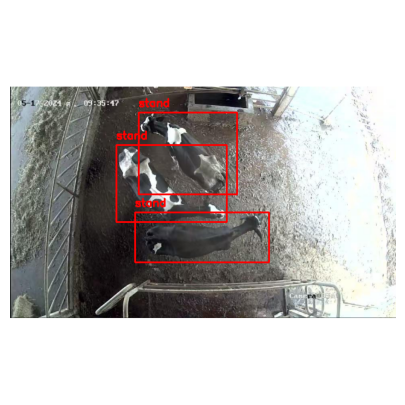

  3%|▎         | 9/269 [00:01<00:31,  8.15it/s]

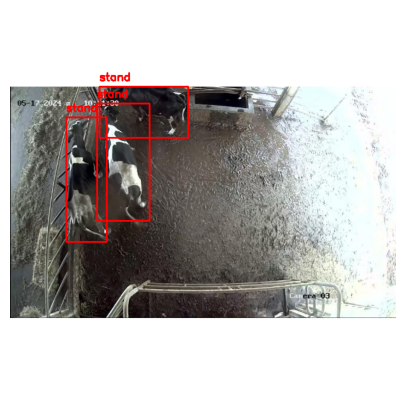

  4%|▎         | 10/269 [00:01<00:32,  8.00it/s]

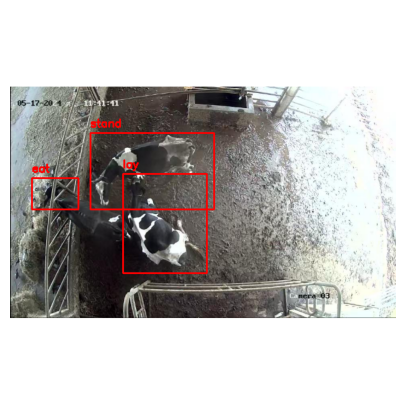

  4%|▍         | 11/269 [00:01<00:32,  7.93it/s]

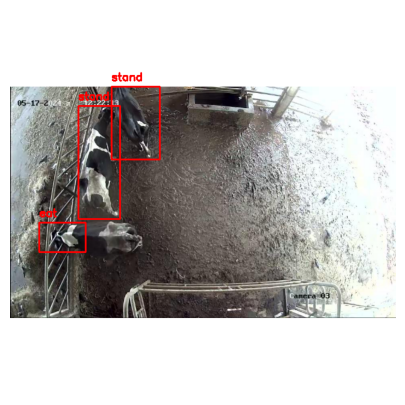

  4%|▍         | 12/269 [00:01<00:32,  7.82it/s]

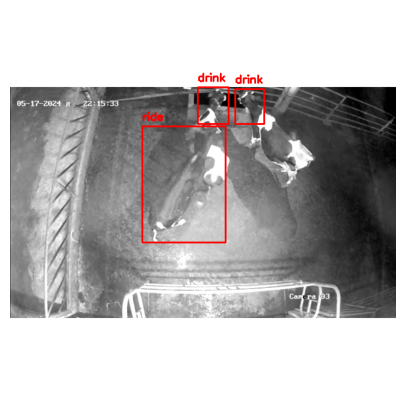

  5%|▍         | 13/269 [00:01<00:34,  7.50it/s]

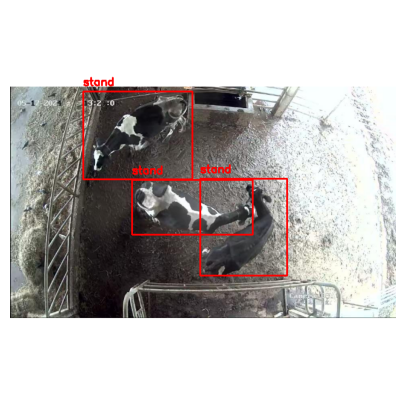

  5%|▌         | 14/269 [00:01<00:34,  7.45it/s]

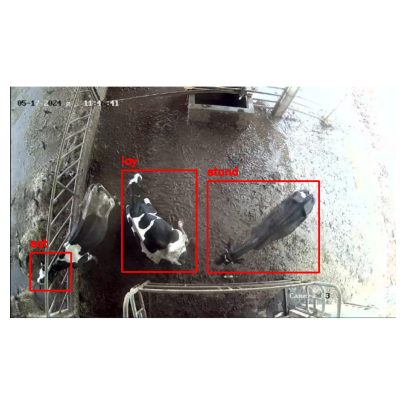

  6%|▌         | 15/269 [00:01<00:34,  7.46it/s]

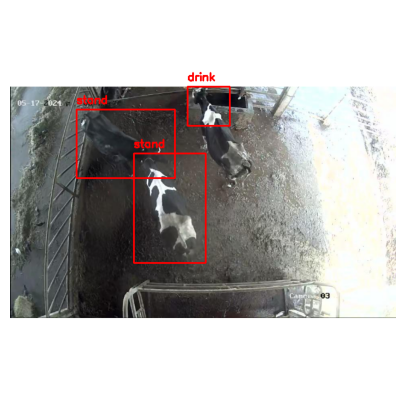

  6%|▌         | 16/269 [00:02<00:35,  7.22it/s]

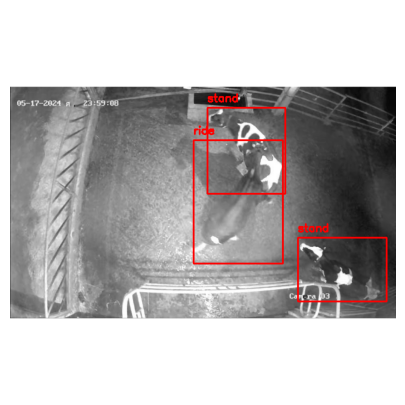

  6%|▋         | 17/269 [00:02<00:33,  7.42it/s]

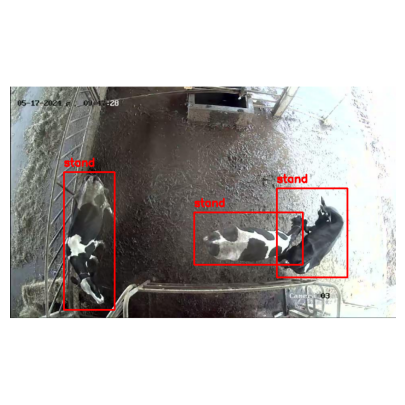

  7%|▋         | 18/269 [00:02<00:34,  7.36it/s]

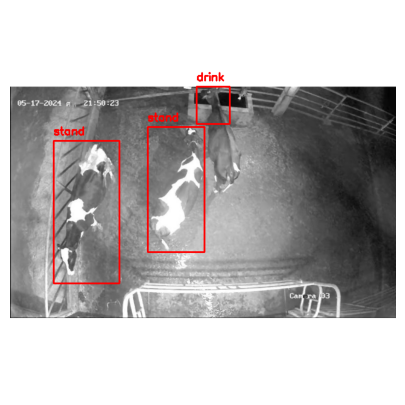

100%|██████████| 269/269 [00:07<00:00, 37.24it/s]

A3 Dataset fixed for test data using white edge method


In [12]:
if camera =="A3":
  #fix_dataset_A3(dataset,A3_fix_method) #fix_dataset_A3(dataset,"white edge")
  fix_dataset_A3(dataset2,A3_fix_method)
  #print(f"A3 Dataset fixed for train/valid data using {A3_fix_method} method")
  print(f"A3 Dataset fixed for test data using {A3_fix_method} method")

# **Test Model**

In [13]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.7 MB/s eta 0:00:00


In [14]:
from ultralytics import YOLO
from ultralytics.data.dataset import YOLODataset
import ultralytics.data.build as build
import numpy as np
import matplotlib.pyplot as plt
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [15]:
import os
import re

def get_latest_run(base_dir="runs/detect", prefix="train"):
    """
    Get the latest folder (e.g., train, val) with a given prefix in runs/detect.
    """
    if not os.path.exists(base_dir):
        return None

    # Filter directories that start with the specified prefix
    subdirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and d.startswith(prefix)]

    # Function to extract numeric suffixes (e.g., train3 -> 3, train -> 0)
    def get_suffix(name):
        match = re.match(rf"{prefix}(\d*)", name)
        return int(match.group(1)) if match and match.group(1).isdigit() else 0

    # Find the subdir with the highest suffix
    latest = max(subdirs, key=get_suffix, default=None)
    return os.path.join(base_dir, latest) if latest else None

# Example usage:
latest_train_path = get_latest_run(prefix="train")
#latest_val_path = get_latest_run(prefix="val")

print("Latest train folder:", latest_train_path)
#print("Latest val folder:", latest_val_path)

Latest train folder: None


In [16]:
def calculate_iou(box1, box2):
    """Calculate IoU between two YOLO-format boxes: [x_center, y_center, w, h]"""
    def to_corners(box):
        x1 = box[0] - box[2] / 2
        y1 = box[1] - box[3] / 2
        x2 = box[0] + box[2] / 2
        y2 = box[1] + box[3] / 2
        return x1, y1, x2, y2

    x1_min, y1_min, x1_max, y1_max = to_corners(box1)
    x2_min, y2_min, x2_max, y2_max = to_corners(box2)

    inter_x1 = max(x1_min, x2_min)
    inter_y1 = max(y1_min, y2_min)
    inter_x2 = min(x1_max, x2_max)
    inter_y2 = min(y1_max, y2_max)

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = area1 + area2 - inter_area

    return inter_area / union_area if union_area > 0 else 0

In [17]:
def xywh_to_xyxy(x_center, y_center, w, h, img_w, img_h):
    x1 = int((x_center - w / 2) * img_w)
    y1 = int((y_center - h / 2) * img_h)
    x2 = int((x_center + w / 2) * img_w)
    y2 = int((y_center + h / 2) * img_h)
    return x1, y1, x2, y2

def draw_boxes(image, boxes, class_names, color=(0, 0, 255)):
    h, w = image.shape[:2]
    for cls, x, y, bw, bh, conf in boxes:
        x1, y1, x2, y2 = xywh_to_xyxy(x, y, bw, bh, w, h)
        label = class_names[int(cls)]
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, label, (x1, max(20, y1 - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return image

In [18]:
import yaml
import os
with open(os.path.join(dataset2.location, "data.yaml")) as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml["names"]  # List of class names

In [20]:
#ตรงนี้ควรจะมา test กับข้อมูลวันที่ 17 พ.ค. อีกที โดยใช้ best confidence threshold
import yaml
from sklearn.metrics import f1_score
# Load the trained model from the original training folder


model2 = YOLO('/content/drive/MyDrive/cow A3/Model/Model_Cow_Top_View.pt')
best_conf = 0.5

#Suppression for A3
import numpy as np

def _yolo_to_xyxy(box):
    # box = [cls, xc, yc, w, h, conf]  (all normalized 0..1 is fine)
    _, xc, yc, w, h, _ = box
    x1 = xc - w / 2.0
    y1 = yc - h / 2.0
    x2 = xc + w / 2.0
    y2 = yc + h / 2.0
    return x1, y1, x2, y2

def _iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    iw = max(0.0, inter_x2 - inter_x1)
    ih = max(0.0, inter_y2 - inter_y1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter + 1e-9
    return inter / union

def suppress_overlaps(pred_boxes, iou_thresh=0.90):
    """
    Remove near-duplicate boxes across ALL classes.
    pred_boxes: list of [cls, xc, yc, w, h, conf]
    Returns:
        keep (list): filtered boxes
        suppressed_occurred (bool): True if any box was suppressed
    """
    if not pred_boxes:
        return [], False

    # ensure 6 elements and cast to float
    boxes = []
    for b in pred_boxes:
        if len(b) < 6:
            continue
        cls, xc, yc, w, h, conf = b[:6]
        boxes.append([int(cls), float(xc), float(yc), float(w), float(h), float(conf)])

    if not boxes:
        return [], False

    # sort by confidence desc
    boxes = sorted(boxes, key=lambda x: x[5], reverse=True)

    xyxy = [ _yolo_to_xyxy(b) for b in boxes ]
    suppressed = [False] * len(boxes)
    keep = []
    suppressed_occurred = False

    for i in range(len(boxes)):
        if suppressed[i]:
            continue
        keep.append(boxes[i])  # keep the highest-conf in this cluster
        for j in range(i+1, len(boxes)):
            if suppressed[j]:
                continue
            if _iou_xyxy(xyxy[i], xyxy[j]) > iou_thresh:
                suppressed[j] = True
                suppressed_occurred = True  # suppression happened

    return keep, suppressed_occurred

#Create dummy train and val directory to prevent errors
os.makedirs(f'{dataset2.location}/dummy/train/images', exist_ok=True)
os.makedirs(f'{dataset2.location}/dummy/valid/images', exist_ok=True)

yaml_path = f"{dataset2.location}/data.yaml"  # Change to actual path, test dataset
# Load the YAML file
with open(yaml_path, 'r') as f:
  data = yaml.safe_load(f)

# Modify the paths of train and val to point to dummy folders
data['train'] = '../dummy/train/images'
data['val']   = '../dummy/valid/images'

 # Save the updated YAML file
with open(yaml_path, 'w') as f:
  yaml.dump(data, f)

# Run validation on a different dataset
# results = model2.val(
#     data=f"{dataset2.location}/data.yaml",  # <<-- Use the new dataset here
#     split='test',          # using the test set of the new dataset
#     conf=0.25,            # confidence threshold
#     save_txt=True,        # save predictions in YOLO txt format
#     save_conf=True        # include confidence scores in saved files
# )

results = model2.predict(
    source=f"{dataset2.location}/test/images",
    data=f"{dataset2.location}/data.yaml",  # <<-- Use the new dataset here
    split='test',          # using the test set of the new dataset
    conf=0.5,            # confidence threshold
    save_txt=True,        # save predictions in YOLO txt format
    save_conf=True        # include confidence scores in saved files
)

latest_test_path = get_latest_run(prefix="val")

true_classes = []
pred_classes = []

true_dir = dataset2.location + "/test/labels" #เขียนแบบนี้จะได้ไม่ต้องเปลี่ยนบ่อย
true_dir_images = dataset2.location + "/test/images"
#pred_dir = latest_test_path+'/labels/'
pred_dir = f"/content/runs/detect/predict/labels/"
#runs/detect/val1

for filename in os.listdir(true_dir):
    if filename.endswith('.txt'):
        true_path = os.path.join(true_dir, filename)
        pred_path = os.path.join(pred_dir, filename)
        image_path = os.path.join(true_dir_images, filename.replace('.txt', '.jpg'))

        # Read true boxes: [cls, x_center, y_center, w, h]
        with open(true_path, 'r') as f:
            true_boxes = [list(map(float, line.strip().split())) for line in f]

        # Load predicted boxes (filter by confidence -> Now using best_conf)
        if os.path.exists(pred_path):
            with open(pred_path, 'r') as f:
                pred_boxes = [
                    list(map(float, line.strip().split()))
                    for line in f
                    if len(line.strip().split()) == 6 and float(line.strip().split()[5]) >= best_conf
                ]
        else:
            pred_boxes = []
        if camera=="A3":
          pred_boxes, suppressed_flag = suppress_overlaps(pred_boxes, iou_thresh=0.9)


        used_preds = set()
        #This one can try
        for t_cls, *t_box in true_boxes:
            best_iou = 0
            best_pred_cls = -1
            best_pred_idx = -1
            for i, (p_cls, *p_box) in enumerate(pred_boxes):
                if i in used_preds:
                    continue
                iou = calculate_iou(t_box, p_box)
                if iou > best_iou:
                    best_iou = iou
                    best_pred_cls = p_cls
                    best_pred_idx = i

            true_classes.append(int(t_cls))
            if best_iou > IOU_MATCH_THRESHOLD:
                pred_classes.append(int(best_pred_cls))
                used_preds.add(best_pred_idx)
            else:
                pred_classes.append(-1)  # unmatched, count as miss

          # Optional: if predictions left over that did not match any ground truth, they’re false positives
        for i, (p_cls, *_p_box) in enumerate(pred_boxes):
            if i not in used_preds:
                true_classes.append(-1)           # no GT
                pred_classes.append(int(p_cls))   # predicted cow


# Ensure true and predicted lengths match if needed
print(f"True class length {len(true_classes)}")
print(f"Predicted class length {len(pred_classes)}")

# min_len = min(len(true_classes), len(pred_classes))
# y_true = np.array(true_classes[:min_len])
# y_pred = np.array(pred_classes[:min_len])
y_true=true_classes
y_pred=pred_classes
# Class names (update as needed)
#class_names = ['standing', 'laying', 'eating', 'drinking', 'chin resting', 'riding'] #ต้องแก้ให้ตรงกับใน roboflow

# Add -1 as a valid label for "missed prediction"
labels = list(range(len(class_names))) + [-1]
extended_class_names = class_names + ["background"]

# Compute F1 scores including the 'miss' class
f1_scores = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)

# Print per-class F1
print("\nF1-score per class (including 'background'):")
for i, score in enumerate(f1_scores):
    print(f"{extended_class_names[i]}: {score:.4f}")


image 1/269 /content/1705-cowlebel-A03-8/test/images/A03_20240517_07_43_12_jpg.rf.1265a39ac0425897d59b1495e6f96d89.jpg: 640x640 3 stands, 62.6ms
image 2/269 /content/1705-cowlebel-A03-8/test/images/A03_20240517_07_47_36_jpg.rf.ecea45523d04b5eb4a3138381e7f002e.jpg: 640x640 3 stands, 62.5ms
image 3/269 /content/1705-cowlebel-A03-8/test/images/A03_20240517_07_48_03_jpg.rf.e0d58e95791c7665c240ee16d7a753f3.jpg: 640x640 3 stands, 58.1ms
image 4/269 /content/1705-cowlebel-A03-8/test/images/A03_20240517_07_49_53_jpg.rf.05cc6b1fe1745c80426b3c6b40aa7b59.jpg: 640x640 2 stands, 52.2ms
image 5/269 /content/1705-cowlebel-A03-8/test/images/A03_20240517_07_50_32_jpg.rf.c16e495be7663e8e9e6ac365fef10303.jpg: 640x640 2 stands, 52.2ms
image 6/269 /content/1705-cowlebel-A03-8/test/images/A03_20240517_07_51_25_jpg.rf.df8a9c9c11e5258db99aad51ca5febb4.jpg: 640x640 3 stands, 51.2ms
image 7/269 /content/1705-cowlebel-A03-8/test/images/A03_20240517_07_51_48_jpg.rf.c7fdcda4cb25dfb258121f7fe85018f4.jpg: 640x640 3

In [21]:
!pip install ultralytics ensemble_boxes

# **Test Fine-Tuning Model**

In [24]:
import yaml
import os
import numpy as np
from sklearn.metrics import f1_score
from datetime import datetime
import cv2
from ultralytics import YOLO

# =====================================
# Load Models
# =====================================
modelA = YOLO('/content/drive/MyDrive/cow A3/Model/Finetune_Drinking.pt')
modelB = YOLO('/content/drive/MyDrive/cow A3/Model/Finetune_Chinresting.pt')
modelC = YOLO('/content/drive/MyDrive/cow A3/Model/Finetune_Mounting.pt')
modelD = YOLO('/content/drive/MyDrive/cow A3/Model/Model_Cow_Top_View.pt')

models = [modelA, modelB, modelC, modelD]

# =====================================
# ฟังก์ชันแปลง YOLO → XYXY
# =====================================
def yolo_to_xyxy(box, img_w, img_h):
    cls, cx, cy, w, h = box
    x1 = (cx - w/2) * img_w
    y1 = (cy - h/2) * img_h
    x2 = (cx + w/2) * img_w
    y2 = (cy + h/2) * img_h
    return int(cls), x1, y1, x2, y2

# =====================================
# IoU
# =====================================
def calculate_iou(b1, b2):
    x1,y1,x2,y2 = b1
    xx1,yy1,xx2,yy2 = b2

    xi1 = max(x1, xx1)
    yi1 = max(y1, yy1)
    xi2 = min(x2, xx2)
    yi2 = min(y2, yy2)

    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    area1 = (x2 - x1)*(y2 - y1)
    area2 = (xx2 - xx1)*(yy2 - yy1)

    return inter / (area1 + area2 - inter + 1e-6)

# =====================================
# Ensemble NMS
# =====================================
def ensemble_nms(preds, iou_thresh=0.6):
    preds = sorted(preds, key=lambda x: x[1], reverse=True)
    keep = []

    while preds:
        best = preds.pop(0)
        keep.append(best)
        preds = [
            p for p in preds
            if calculate_iou(best[2:], p[2:]) < iou_thresh
        ]
    return keep

# =====================================
# เตรียม Test
# =====================================
true_classes = []
pred_classes = []

true_dir  = dataset2.location + "/test/labels"
true_imgs = dataset2.location + "/test/images"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_root = f"/content/misclassified_images_{timestamp}"
os.makedirs(save_root, exist_ok=True)

# custom config
IOU_MATCH_THRESHOLD = 0.4
best_conf = 0.35

# Load data.yaml within this cell to ensure 'data' is defined
with open(os.path.join(dataset2.location, "data.yaml")) as f:
    data = yaml.safe_load(f)
class_names = data['names']

# =====================================
# Run ทุกภาพ
# =====================================
for filename in os.listdir(true_dir):

    if not filename.endswith(".txt"):
        continue

    txt_path = os.path.join(true_dir, filename)
    img_path = os.path.join(true_imgs, filename.replace(".txt", ".jpg"))

    img = cv2.imread(img_path)
    H, W = img.shape[:2]

    # ------------ Load GT ------------
    with open(txt_path, "r") as f:
        raw_gt = [list(map(float, line.split())) for line in f]

    true_boxes = [yolo_to_xyxy(box, W, H) for box in raw_gt]   # <-- FIXED (สำคัญมาก)

    # ------------ Ensemble Predict ------------
    all_preds = []

    for model in models:
        pred = model.predict(img_path, conf=best_conf, save=False, verbose=False)[0]
        for box in pred.boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            x1,y1,x2,y2 = box.xyxy[0].cpu().numpy().tolist()

            all_preds.append([cls, conf, x1, y1, x2, y2])

    pred_boxes = ensemble_nms(all_preds, iou_thresh=0.6)

    # Track ใช้ไปแล้ว
    used_preds = set()

    # =====================================
    # MATCH GT → PRED
    # =====================================
    for t_cls, *t_box in true_boxes:

        best_iou = 0
        best_pred_cls = -1
        best_pred_idx = -1

        for i,(p_cls, p_conf, x1,y1,x2,y2) in enumerate(pred_boxes):
            if i in used_preds:
                continue
            iou = calculate_iou(t_box, (x1,y1,x2,y2))
            if iou > best_iou:
                best_iou = iou
                best_pred_cls = p_cls
                best_pred_idx = i

        # Add true label
        true_classes.append(int(t_cls))

        # -------------------------------
        # MATCH SUCCESS
        # -------------------------------
        if best_iou > IOU_MATCH_THRESHOLD:
            pred_classes.append(int(best_pred_cls))
            used_preds.add(best_pred_idx)

            if best_pred_cls != t_cls:
                save_dir = os.path.join(save_root, f"pred_{class_names[best_pred_cls]}_true_{class_names[int(t_cls)]}")
                os.makedirs(save_dir, exist_ok=True)
                cv2.imwrite(os.path.join(save_dir, filename.replace(".txt",".jpg")), img)

        # -------------------------------
        # MISS → background
        # -------------------------------
        else:
            pred_classes.append(-1)
            save_dir = os.path.join(save_root, f"pred_background_true_{class_names[int(t_cls)]}")
            os.makedirs(save_dir, exist_ok=True)
            cv2.imwrite(os.path.join(save_dir, filename.replace(".txt",".jpg")), img)

    # =====================================
    # False Positive (PRED ไม่มี GT)
    # =====================================
    for i,(p_cls, *_box) in enumerate(pred_boxes):
        if i not in used_preds:
            true_classes.append(-1)
            pred_classes.append(int(p_cls))

            save_dir = os.path.join(save_root, f"pred_{class_names[int(p_cls)]}_true_background")
            os.makedirs(save_dir, exist_ok=True)
            cv2.imwrite(os.path.join(save_dir, filename.replace(".txt",".jpg")), img)

# =====================================
# F1-score
# =====================================
labels = list(range(len(class_names))) + [-1]
extended_names = class_names + ["background"]

f1_scores = f1_score(true_classes, pred_classes, labels=labels, average=None, zero_division=0)

print("\nF1-score per class:")
for i, s in enumerate(f1_scores):
    print(f"{extended_names[i]}: {s:.4f}")


F1-score per class:
drink: 0.6111
eat: 0.7965
lay: 0.8070
propping: 0.6250
ride: 0.7302
stand: 0.8202
background: 0.0000
